# Sentiment Analysis Optimization using Bio Inspired Algorithm
## Dataset provided : https://archive.ics.uci.edu/dataset/331/sentiment+labelled+sentences
3 TSV Files 
### Members 
- Aniruddha Panchal
- kinjal Surve
- Tanuj Balivada
- Vanshika Chinchkhede

Models experimented :
- KNN (F1 )
- KNN (SPECIFICITY)

- RANDOM FOREST (F1)
- RANDOM FOREST (SPECIFICITY)

- DECISION TREE (F1)
- DECISION TREE (SPECIFICITY)

- SUM (F1)
- SUM (SPECIFICITY)

- GRADIENT B (F1)
- GRADIENT B (SPECIFICITY)

- XGRADIENT B (F1)
- XGRADIENT B (SPECIFICITY)

Algorithms : 
- Particle Swarm Optimization (PSO) – inspired by bird flocking/fish schooling.

- Genetic Algorithm (GA) – based on natural selection and evolution.

- Ant Colony Optimization (ACO) – mimics how ants find shortest paths.

- Bat Algorithm – inspired by echolocation of bats.

- Cuckoo Search – mimics cuckoo birds laying eggs in other nests.

- Firefly Algorithm – based on fireflies attracting each other with light.

- Artificial Bee Colony (ABC) – inspired by honeybee foraging behavior.

## Dataset analysis 

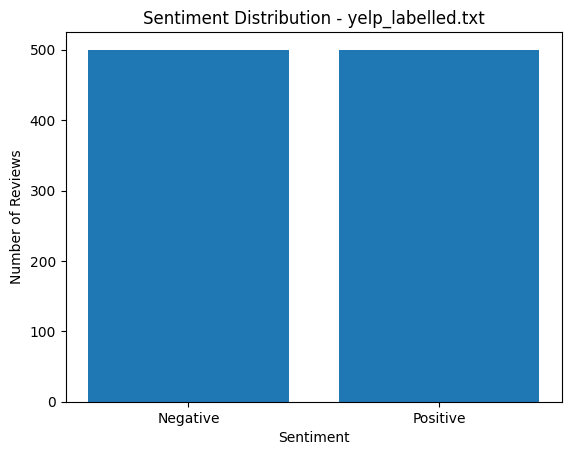

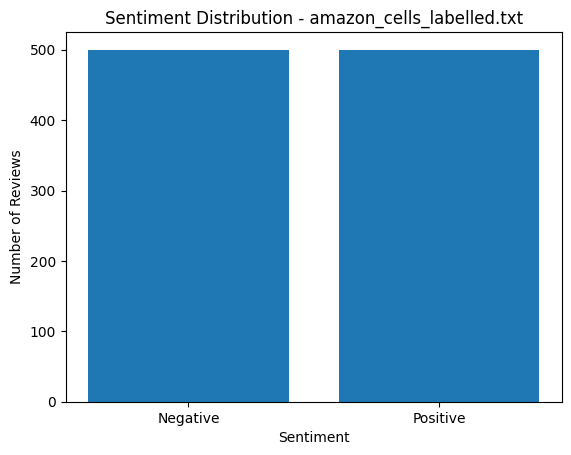

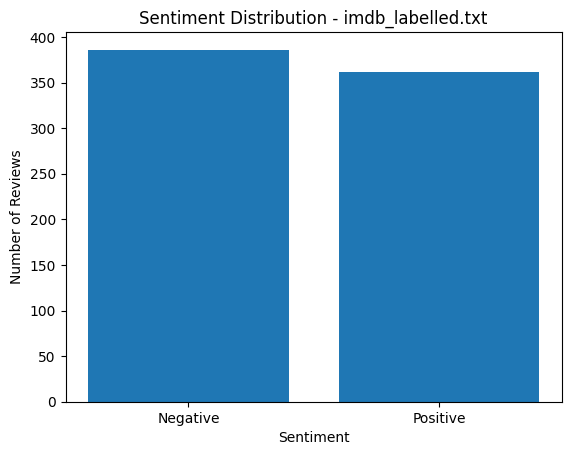

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# List of files
files = ['yelp_labelled.txt', "amazon_cells_labelled.txt", 'imdb_labelled.txt']

# Loop through files
for file in files:
    df = pd.read_csv(file, sep='\t', header=None, names=['text', 'label'])
    counts = df['label'].value_counts()
    
    plt.bar(['Negative', 'Positive'], counts)
    plt.title(f'Sentiment Distribution - {file}')
    plt.xlabel('Sentiment')
    plt.ylabel('Number of Reviews')
    plt.show()


 The data in the first two datasets is roughly balanced between positive and negative classes, whereas the third dataset (IMDb ratings) has a slightly higher number of negative samples; however, this minor imbalance can be safely ignored.

# KNN





## KNN (PSO)

In [6]:
import pandas as pd

files = ["yelp_labelled.txt", "imdb_labelled.txt", "amazon_cells_labelled.txt"]

dfs = [pd.read_csv(f, sep='\t', header=None, names=['statement', 'value']) for f in files]

data = pd.concat(dfs, ignore_index=True)

X = data['statement']
y = data['value']


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

vectorizer = CountVectorizer(max_features=500)  # limit vocab for PSO
X_train_vect = vectorizer.fit_transform(X_train)
X_test_vect = vectorizer.transform(X_test)


In [8]:
from pyswarm import pso
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import f1_score
import numpy as np

def objective(features_mask):
    features_mask = np.array(features_mask) > 0.5
    if np.sum(features_mask) == 0:
        return 1.0  # penalty for empty feature set
    X_train_sel = X_train_vect[:, features_mask]
    X_test_sel = X_test_vect[:, features_mask]
    
    model = MultinomialNB()
    model.fit(X_train_sel, y_train)
    y_pred = model.predict(X_test_sel)
    f1 = f1_score(y_test, y_pred)
    return 1 - f1  # PSO minimizes


In [9]:
num_features = X_train_vect.shape[1]
lb = [0] * num_features
ub = [1] * num_features

best_features, best_cost = pso(objective, lb, ub, swarmsize=10, maxiter=5)

print("Best F1 Score:", 1 - best_cost)

knn_pso_f1 = 1 - best_cost

Stopping search: maximum iterations reached --> 5
Best F1 Score: 0.764378478664193


In [10]:
from sklearn.metrics import confusion_matrix, f1_score

best_mask = np.array(best_features) > 0.5

X_train_sel = X_train_vect[:, best_mask]
X_test_sel = X_test_vect[:, best_mask]

model = MultinomialNB()
model.fit(X_train_sel, y_train)
y_pred = model.predict(X_test_sel)

f1 = f1_score(y_test, y_pred)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)

print("Specificity:", specificity)
knn_pso_specificity = specificity


Specificity: 0.7281879194630873


## KNN (GA)

In [11]:
import random
import numpy as np
from deap import base, creator, tools
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score, confusion_matrix

num_features = X_train_vect.shape[1]

creator.create("FitnessMax", base.Fitness, weights=(1.0,))  
creator.create("Individual", list, fitness=creator.FitnessMax)

toolbox = base.Toolbox()
toolbox.register("attr_bool", random.randint, 0, 1)  
toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_bool, n=num_features)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)


In [12]:
def fitness(individual):
    mask = np.array(individual) > 0
    if np.sum(mask) == 0: 
        return 0,
    
    X_train_sel = X_train_vect[:, mask]
    X_test_sel = X_test_vect[:, mask]
    
    model = KNeighborsClassifier(n_neighbors=5)
    model.fit(X_train_sel, y_train)
    y_pred = model.predict(X_test_sel)
    
    f1 = f1_score(y_test, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    specificity = tn / (tn + fp)
    
    score = (f1 + specificity) / 2
    return score,
    
toolbox.register("evaluate", fitness)
toolbox.register("mate", tools.cxTwoPoint)
toolbox.register("mutate", tools.mutFlipBit, indpb=0.05)
toolbox.register("select", tools.selTournament, tournsize=3)


In [13]:
population = toolbox.population(n=20)
NGEN = 10 

for gen in range(NGEN):
    offspring = toolbox.select(population, len(population))
    offspring = list(map(toolbox.clone, offspring))
    
    for child1, child2 in zip(offspring[::2], offspring[1::2]):
        if random.random() < 0.5:
            toolbox.mate(child1, child2)
            del child1.fitness.values
            del child2.fitness.values
    
    for mutant in offspring:
        if random.random() < 0.2:
            toolbox.mutate(mutant)
            del mutant.fitness.values
    
    invalid_ind = [ind for ind in offspring if not ind.fitness.valid]
    fitnesses = map(toolbox.evaluate, invalid_ind)
    for ind, fit in zip(invalid_ind, fitnesses):
        ind.fitness.values = fit
    
    population[:] = offspring

best_ind = tools.selBest(population, 1)[0]
print("Best F1+Specificity Score:", fitness(best_ind)[0])
selected_features = np.where(np.array(best_ind) > 0)[0]


Best F1+Specificity Score: 0.6719438382673859


In [14]:
X_train_sel = X_train_vect[:, selected_features]
X_test_sel = X_test_vect[:, selected_features]
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train_sel, y_train)
y_pred = model.predict(X_test_sel)

f1 = f1_score(y_test, y_pred)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)

print("Final F1 Score:", f1)
print("Final Specificity:", specificity)

knn_ga_f1 = f1
knn_ga_specificity = specificity


Final F1 Score: 0.6257668711656442
Final Specificity: 0.7181208053691275


## KNN (ANT)

In [15]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score, confusion_matrix
import random

num_features = X_train_vect.shape[1]

# ACO parameters
num_ants = 20
num_iterations = 10
pheromone = np.ones(num_features)
alpha = 1  # influence of pheromone
beta = 2   # influence of heuristic (we'll use uniform)
evaporation = 0.1

best_score = 0
best_features = None

for iteration in range(num_iterations):
    all_solutions = []
    all_scores = []

    for ant in range(num_ants):
        # Construct solution probabilistically
        prob = (pheromone ** alpha) * (np.ones(num_features) ** beta)
        prob = prob / np.sum(prob)
        selected = np.random.rand(num_features) < prob  # binary mask
        
        if np.sum(selected) == 0:
            selected[random.randint(0, num_features-1)] = True  # ensure at least 1 feature
        
        X_train_sel = X_train_vect[:, selected]
        X_test_sel = X_test_vect[:, selected]
        
        model = KNeighborsClassifier(n_neighbors=5)
        model.fit(X_train_sel, y_train)
        y_pred = model.predict(X_test_sel)
        
        f1 = f1_score(y_test, y_pred)
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
        specificity = tn / (tn + fp)
        score = (f1 + specificity) / 2  # combined metric

        all_solutions.append(selected)
        all_scores.append(score)

        # Update best
        if score > best_score:
            best_score = score
            best_features = selected

    # Evaporate pheromones
    pheromone = (1 - evaporation) * pheromone

    # Deposit pheromone proportional to score
    for sol, score in zip(all_solutions, all_scores):
        pheromone += sol * score

    print(f"Iteration {iteration+1}, Best Score so far: {best_score:.4f}")

# Selected feature indices
selected_indices = np.where(best_features)[0]
print("Selected Feature Indices:", selected_indices)


Iteration 1, Best Score so far: 0.5741
Iteration 2, Best Score so far: 0.5741
Iteration 3, Best Score so far: 0.5741
Iteration 4, Best Score so far: 0.5741
Iteration 5, Best Score so far: 0.5741
Iteration 6, Best Score so far: 0.5741
Iteration 7, Best Score so far: 0.6054
Iteration 8, Best Score so far: 0.6054
Iteration 9, Best Score so far: 0.6054
Iteration 10, Best Score so far: 0.6054
Selected Feature Indices: [181]


In [16]:
X_train_sel = X_train_vect[:, selected_indices]
X_test_sel = X_test_vect[:, selected_indices]

model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train_sel, y_train)
y_pred = model.predict(X_test_sel)

f1 = f1_score(y_test, y_pred)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)

print("Final F1 Score:", f1)
print("Final Specificity:", specificity)

knn_ant_f1 = f1
knn_ant_specificity = specificity

Final F1 Score: 0.21754385964912282
Final Specificity: 0.9932885906040269


## KNN (BAT)

In [17]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score, confusion_matrix
import random

num_features = X_train_vect.shape[1]

n_bats = 20
n_iterations = 10
A = 0.5 
r = 0.5 
f_min, f_max = 0, 1
alpha, gamma = 0.9, 0.9 

positions = np.random.rand(n_bats, num_features) > 0.5  # binary mask
velocities = np.zeros((n_bats, num_features))
best_score = 0
best_position = None


In [18]:
def fitness(position):
    mask = position.astype(bool)
    if np.sum(mask) == 0:
        return 0
    X_train_sel = X_train_vect[:, mask]
    X_test_sel = X_test_vect[:, mask]
    model = KNeighborsClassifier(n_neighbors=5)
    model.fit(X_train_sel, y_train)
    y_pred = model.predict(X_test_sel)
    f1 = f1_score(y_test, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    specificity = tn / (tn + fp)
    return (f1 + specificity) / 2


In [19]:
for t in range(n_iterations):
    for i in range(n_bats):
        f = f_min + (f_max - f_min) * random.random()
        velocities[i] += (positions[i] ^ (best_position if best_position is not None else positions[i])) * f
        new_pos = positions[i] ^ (velocities[i] > 0.5)  # XOR for binary update

        if random.random() > r: 
            new_pos = positions[i] ^ (np.random.rand(num_features) > 0.5)

        score = fitness(new_pos)
        if score > fitness(positions[i]) and random.random() < A:
            positions[i] = new_pos
            A *= alpha
            r = r * (1 - np.exp(-gamma * t))

        if score > best_score:
            best_score = score
            best_position = new_pos

    print(f"Iteration {t+1}, Best Score so far: {best_score:.4f}")

selected_features = np.where(best_position)[0]


Iteration 1, Best Score so far: 0.6470
Iteration 2, Best Score so far: 0.6586
Iteration 3, Best Score so far: 0.6586
Iteration 4, Best Score so far: 0.6586
Iteration 5, Best Score so far: 0.6974
Iteration 6, Best Score so far: 0.6974
Iteration 7, Best Score so far: 0.6974
Iteration 8, Best Score so far: 0.6974
Iteration 9, Best Score so far: 0.6974
Iteration 10, Best Score so far: 0.6974


In [20]:
X_train_sel = X_train_vect[:, selected_features]
X_test_sel = X_test_vect[:, selected_features]

model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train_sel, y_train)
y_pred = model.predict(X_test_sel)

f1 = f1_score(y_test, y_pred)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)

print("Final F1 Score:", f1)
print("Final Specificity:", specificity)

knn_bat_f1 = f1
knn_bat_specificity = specificity


Final F1 Score: 0.659919028340081
Final Specificity: 0.7348993288590604


## KNN (CUKOO)

In [21]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score, confusion_matrix
import random

num_features = X_train_vect.shape[1]
n_nests = 20
n_iterations = 10
pa = 0.25 
best_score = 0
best_nest = None

nests = np.random.rand(n_nests, num_features) > 0.5


In [22]:
def fitness(position):
    mask = position.astype(bool)
    if np.sum(mask) == 0:
        return 0
    X_train_sel = X_train_vect[:, mask]
    X_test_sel = X_test_vect[:, mask]
    model = KNeighborsClassifier(n_neighbors=5)
    model.fit(X_train_sel, y_train)
    y_pred = model.predict(X_test_sel)
    f1 = f1_score(y_test, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    specificity = tn / (tn + fp)
    return (f1 + specificity) / 2


In [23]:
import math
import numpy as np
import random

def levy_flight(Lambda=1.5):
    sigma = (math.gamma(1 + Lambda) * math.sin(math.pi * Lambda / 2) /
             (math.gamma((1 + Lambda) / 2) * Lambda * 2 ** ((Lambda - 1) / 2))) ** (1 / Lambda)
    u = np.random.randn(num_features) * sigma
    v = np.random.randn(num_features)
    step = u / np.abs(v) ** (1 / Lambda)
    return step

for t in range(n_iterations):
    for i in range(n_nests):
        step = levy_flight()
        new_nest = nests[i] ^ (np.random.rand(num_features) < np.abs(step))  # XOR update

        if np.sum(new_nest) == 0:
            new_nest[random.randint(0, num_features-1)] = True

        score = fitness(new_nest)

        if score > fitness(nests[i]):
            nests[i] = new_nest

        if score > best_score:
            best_score = score
            best_nest = new_nest

    for i in range(n_nests):
        if random.random() < pa:
            nests[i] = np.random.rand(num_features) > 0.5

    print(f"Iteration {t+1}, Best Score so far: {best_score:.4f}")

selected_features = np.where(best_nest)[0]


Iteration 1, Best Score so far: 0.6329
Iteration 2, Best Score so far: 0.6334
Iteration 3, Best Score so far: 0.6608
Iteration 4, Best Score so far: 0.6608
Iteration 5, Best Score so far: 0.6608
Iteration 6, Best Score so far: 0.6637
Iteration 7, Best Score so far: 0.6637
Iteration 8, Best Score so far: 0.6637
Iteration 9, Best Score so far: 0.6637
Iteration 10, Best Score so far: 0.6761


In [24]:
X_train_sel = X_train_vect[:, selected_features]
X_test_sel = X_test_vect[:, selected_features]

model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train_sel, y_train)
y_pred = model.predict(X_test_sel)

f1 = f1_score(y_test, y_pred)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)

print("Final F1 Score:", f1)
print("Final Specificity:", specificity)

knn_cukoo_f1 = f1
knn_cukoo_specificity = specificity

Final F1 Score: 0.6575342465753424
Final Specificity: 0.6946308724832215


## KNN (Firefly Algorithm)

In [25]:
import numpy as np
import random
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score, confusion_matrix

num_features = X_train_vect.shape[1]
n_fireflies = 20
n_iterations = 10
alpha = 0.5 
beta0 = 1.0 
gamma = 1.0  
best_score = 0
best_firefly = None

fireflies = np.random.rand(n_fireflies, num_features) > 0.5

def fitness(position):
    mask = position.astype(bool)
    if np.sum(mask) == 0:
        return 0
    X_train_sel = X_train_vect[:, mask]
    X_test_sel = X_test_vect[:, mask]
    model = KNeighborsClassifier(n_neighbors=5)
    model.fit(X_train_sel, y_train)
    y_pred = model.predict(X_test_sel)
    f1 = f1_score(y_test, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    specificity = tn / (tn + fp)
    return (f1 + specificity) / 2

for t in range(n_iterations):
    for i in range(n_fireflies):
        for j in range(n_fireflies):
            if fitness(fireflies[j]) > fitness(fireflies[i]):
                r = np.sum(fireflies[i] != fireflies[j])
                beta = beta0 * np.exp(-gamma * r ** 2)
                move = beta * (fireflies[j] ^ fireflies[i])
                new_pos = fireflies[i] ^ (move > 0.5)
                new_pos ^= (np.random.rand(num_features) < alpha)
                if np.sum(new_pos) == 0:
                    new_pos[random.randint(0, num_features-1)] = True
                fireflies[i] = new_pos
                score = fitness(new_pos)
                if score > best_score:
                    best_score = score
                    best_firefly = new_pos

    print(f"Iteration {t+1}, Best Score so far: {best_score:.4f}")

selected_features = np.where(best_firefly)[0]


Iteration 1, Best Score so far: 0.6746
Iteration 2, Best Score so far: 0.6746
Iteration 3, Best Score so far: 0.6942
Iteration 4, Best Score so far: 0.6942
Iteration 5, Best Score so far: 0.6942
Iteration 6, Best Score so far: 0.6990
Iteration 7, Best Score so far: 0.7082
Iteration 8, Best Score so far: 0.7082
Iteration 9, Best Score so far: 0.7082
Iteration 10, Best Score so far: 0.7082


In [26]:
X_train_sel = X_train_vect[:, selected_features]
X_test_sel = X_test_vect[:, selected_features]

model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train_sel, y_train)


y_pred = model.predict(X_test_sel)

f1 = f1_score(y_test, y_pred)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)

print("Final F1 Score:", f1)
print("Final Specificity:", specificity)

knn_firefly_f1 = f1
knn_firefly_specificity = specificity


Final F1 Score: 0.6680244399185336
Final Specificity: 0.7483221476510067


## KNN (ABC)

In [27]:
import numpy as np
import random
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score, confusion_matrix

num_features = X_train_vect.shape[1]
n_bees = 20
n_iterations = 10
limit = 5 
best_score = 0
best_solution = None

foods = np.random.rand(n_bees, num_features) > 0.5
trial = np.zeros(n_bees)  

def fitness(position):
    mask = position.astype(bool)
    if np.sum(mask) == 0:
        return 0
    X_train_sel = X_train_vect[:, mask]
    X_test_sel = X_test_vect[:, mask]
    model = KNeighborsClassifier(n_neighbors=5)
    model.fit(X_train_sel, y_train)
    y_pred = model.predict(X_test_sel)
    f1 = f1_score(y_test, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    specificity = tn / (tn + fp)
    return (f1 + specificity) / 2

for t in range(n_iterations):
    for i in range(n_bees):
        k = random.choice([x for x in range(n_bees) if x != i])
        phi = np.random.uniform(-1, 1, num_features)
        new_solution = foods[i] ^ ((foods[i] ^ foods[k]) & (phi > 0))
        if np.sum(new_solution) == 0:
            new_solution[random.randint(0, num_features-1)] = True
        new_score = fitness(new_solution)
        if new_score > fitness(foods[i]):
            foods[i] = new_solution
            trial[i] = 0
        else:
            trial[i] += 1
        if new_score > best_score:
            best_score = new_score
            best_solution = new_solution

    fitness_vals = np.array([fitness(f) for f in foods])
    probs = fitness_vals / (fitness_vals.sum() + 1e-9)
    for i in range(n_bees):
        if random.random() < probs[i]:
            k = random.choice([x for x in range(n_bees) if x != i])
            phi = np.random.uniform(-1, 1, num_features)
            new_solution = foods[i] ^ ((foods[i] ^ foods[k]) & (phi > 0))
            if np.sum(new_solution) == 0:
                new_solution[random.randint(0, num_features-1)] = True
            new_score = fitness(new_solution)
            if new_score > fitness(foods[i]):
                foods[i] = new_solution
                trial[i] = 0
            else:
                trial[i] += 1
            if new_score > best_score:
                best_score = new_score
                best_solution = new_solution

    for i in range(n_bees):
        if trial[i] > limit:
            foods[i] = np.random.rand(num_features) > 0.5
            trial[i] = 0

    print(f"Iteration {t+1}, Best Score so far: {best_score:.4f}")

selected_features = np.where(best_solution)[0]


Iteration 1, Best Score so far: 0.6561
Iteration 2, Best Score so far: 0.6680
Iteration 3, Best Score so far: 0.6824
Iteration 4, Best Score so far: 0.6824
Iteration 5, Best Score so far: 0.7056
Iteration 6, Best Score so far: 0.7056
Iteration 7, Best Score so far: 0.7306
Iteration 8, Best Score so far: 0.7306
Iteration 9, Best Score so far: 0.7306
Iteration 10, Best Score so far: 0.7306


In [28]:
X_train_sel = X_train_vect[:, selected_features]
X_test_sel = X_test_vect[:, selected_features]

model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train_sel, y_train)

y_pred = model.predict(X_test_sel)

f1 = f1_score(y_test, y_pred)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)

print("Final F1 Score:", f1)
print("Final Specificity:", specificity)

knn_abc_f1 = f1
knn_abc_specificity = specificity

Final F1 Score: 0.6491228070175439
Final Specificity: 0.8120805369127517


## visualization


In [29]:
algorithms = ["PSO", "GA", "Bat", "ACO", "Firefly", "ABC", "Cuckoo"]
f1_scores = [knn_pso_f1, knn_ga_f1, knn_bat_f1, knn_ant_f1, knn_firefly_f1, knn_abc_f1, knn_cukoo_f1]
specificity = [knn_pso_specificity, knn_ga_specificity, knn_bat_specificity, knn_ant_specificity,
               knn_firefly_specificity, knn_abc_specificity, knn_cukoo_specificity]


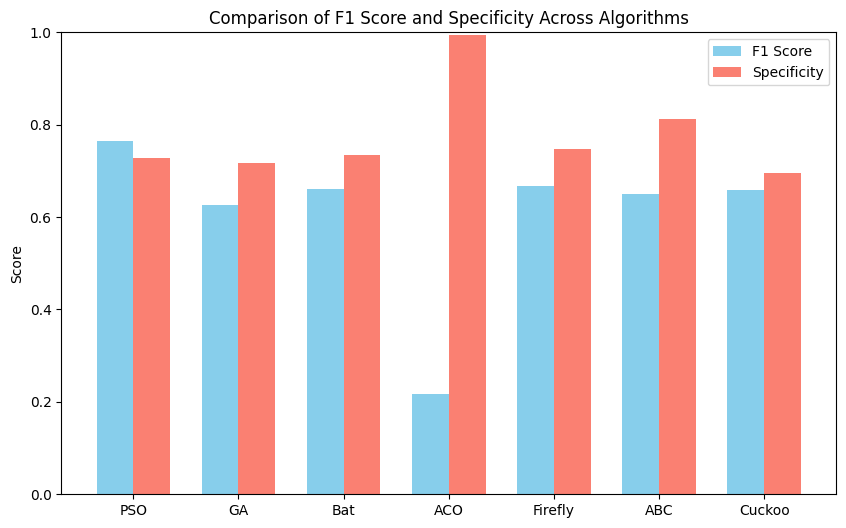

In [30]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(algorithms))
width = 0.35

plt.figure(figsize=(10,6))
plt.bar(x - width/2, f1_scores, width, label='F1 Score', color='skyblue')
plt.bar(x + width/2, specificity, width, label='Specificity', color='salmon')

plt.xticks(x, algorithms)
plt.ylabel('Score')
plt.ylim(0,1)
plt.title('Comparison of F1 Score and Specificity Across Algorithms')
plt.legend()
plt.show()


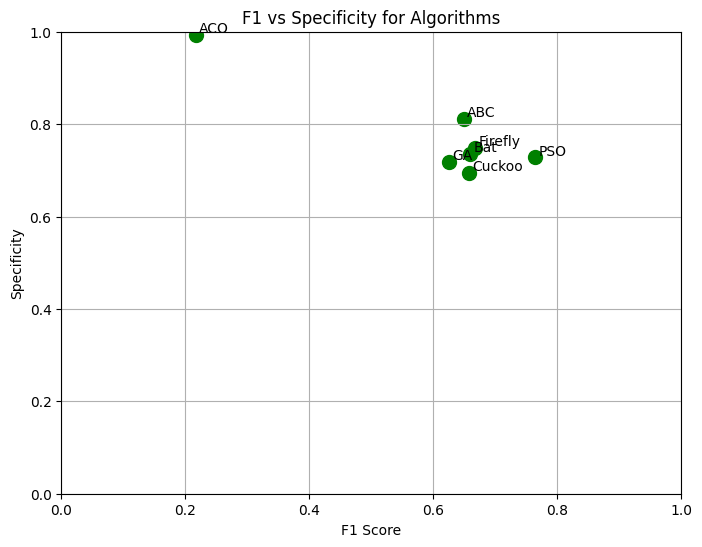

In [31]:
plt.figure(figsize=(8,6))
plt.scatter(f1_scores, specificity, color='green', s=100)

for i, alg in enumerate(algorithms):
    plt.text(f1_scores[i]+0.005, specificity[i]+0.005, alg)

plt.xlabel('F1 Score')
plt.ylabel('Specificity')
plt.title('F1 vs Specificity for Algorithms')
plt.xlim(0,1)
plt.ylim(0,1)
plt.grid(True)
plt.show()


# Random Forest


## Random Forest (PSO)

In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

file_paths = ["imdb_labelled.txt", "yelp_labelled.txt", "amazon_cells_labelled.txt"]
dfs = [pd.read_csv(f, sep="\t", header=None) for f in file_paths]
df_all = pd.concat(dfs, ignore_index=True)

X = df_all[0]  
y = df_all[1]  


# Train-test split
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# TF-IDF vectorization
vectorizer = TfidfVectorizer(max_features=500)
X_train = vectorizer.fit_transform(X_train_text).toarray()
X_test = vectorizer.transform(X_test_text).toarray()


In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, confusion_matrix

def rf_objective(solution):
    n_estimators = int(solution[0])
    max_depth = int(solution[1])
    min_samples_split = int(solution[2])
    min_samples_leaf = int(solution[3])

    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state=42
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    f1 = f1_score(y_test, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    specificity = tn / (tn + fp)

    global rf_pso_f1, rf_pso_specificity
    rf_pso_f1 = f1
    rf_pso_specificity = specificity  


    return 1 - f1


In [46]:
print(f"F1 Score: {float(rf_pso_f1):.4f}")
print(f"Specificity: {float(rf_pso_specificity[0] if isinstance(rf_pso_specificity, list) else rf_pso_specificity):.4f}")


F1 Score: 0.6491
Specificity: 0.7282


## Random Forest (GA)

In [47]:
from mealpy.evolutionary_based import GA
from mealpy.utils.problem import Problem
from mealpy.utils.space import IntegerVar
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, confusion_matrix


In [59]:
def rf_objective(solution):
    n_estimators = max(1, int(solution[0]))
    max_depth = max(1, int(solution[1]))
    min_samples_split = max(2, int(solution[2]))
    min_samples_leaf = max(1, int(solution[3]))

    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state=42
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    f1 = f1_score(y_test, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    specificity = tn / (tn + fp)

    global rf_ga_f1, rf_ga_specificity
    rf_ga_f1 = f1
    rf_ga_specificity = specificity

    return 1 - f1



In [60]:
bounds = [
    IntegerVar(lb=50, ub=300),
    IntegerVar(lb=2, ub=20),
    IntegerVar(lb=2, ub=10),
    IntegerVar(lb=1, ub=5)
]

rf_problem_ga = Problem(
    obj_func=rf_objective,
    bounds=bounds,
    minmax="min"
)


In [ ]:
epoch = 50
pop_size = 20

rf_ga_model = GA.BaseGA(epoch=epoch, pop_size=pop_size)
rf_best_ga = rf_ga_model.solve(problem=rf_problem_ga)


2025/10/09 11:21:23 AM, INFO, mealpy.evolutionary_based.GA.BaseGA: BaseGA(epoch=50, pop_size=20, pc=0.95, pm=0.025)
2025/10/09 11:21:44 AM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 1, Current best: 0.1964285714285714, Global best: 0.1964285714285714, Runtime: 10.77797 seconds
2025/10/09 11:21:55 AM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 2, Current best: 0.19285714285714284, Global best: 0.19285714285714284, Runtime: 11.07292 seconds
2025/10/09 11:22:05 AM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 3, Current best: 0.19580419580419584, Global best: 0.19285714285714284, Runtime: 10.29228 seconds
2025/10/09 11:22:16 AM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 4, Current best: 0.1923076923076923, Global best: 0.1923076923076923, Runtime: 10.82278 seconds
2025/10/09 11:22:27 AM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 5, Current best: 0.1923076923076923, Global best: 0

In [ ]:
print("===== RANDOM FOREST + GA RESULTS =====")
print(f"Best Parameters: {rf_best_ga.solution}")
print(f"F1 Score: {rf_ga_f1:.4f}")
print(f"Specificity: {rf_ga_specificity:.4f}")


===== RANDOM FOREST + GA RESULTS =====
Best Parameters: [229.   7.  10.   2.]
F1 Score: 0.8091
Specificity: 0.7023


## Random Forest (ACO)

In [3]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, confusion_matrix
import PyACO


In [4]:
# Global variables to store metrics
rf_aco_f1 = 0
rf_aco_specificity = 0

def rf_objective(solution):
    global rf_aco_f1, rf_aco_specificity
    
    # Extract hyperparameters (convert to int)
    n_estimators = max(1, int(solution[0]))
    max_depth = max(1, int(solution[1]))
    min_samples_split = max(2, int(solution[2]))
    min_samples_leaf = max(1, int(solution[3]))
    
    # Create RF model
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state=42
    )
    
    # Train and predict
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    # Compute metrics
    f1 = f1_score(y_test, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    specificity = tn / (tn + fp)
    
    # Store globally
    rf_aco_f1 = f1
    rf_aco_specificity = specificity
    
    return 1 - f1  # Minimize 1 - F1


In [2]:
import numpy as np
from PyACO import AntColony

# Define the problem dimensions
n_estimators_bounds = (50, 200)
max_depth_bounds = (5, 50)
min_samples_split_bounds = (2, 20)
min_samples_leaf_bounds = (1, 20)

# Define the number of ants and iterations
n_ants = 10
n_iterations = 50

# Define the pheromone parameters
alpha = 1.0  # Influence of pheromone
beta = 2.0   # Influence of heuristic information
rho = 0.1    # Pheromone evaporation rate

# Define the objective function
def objective_function(solution):
    return rf_objective(solution)

# Initialize the Ant Colony
colony = AntColony(
    n_ants=n_ants,
    n_best=3,
    n_iterations=n_iterations,
    alpha=alpha,
    beta=beta,
    rho=rho,
    q0=0.9,
    seed=42,
    verbose=True
)

# Define the bounds for each hyperparameter
bounds = [
    n_estimators_bounds,
    max_depth_bounds,
    min_samples_split_bounds,
    min_samples_leaf_bounds
]

# Define the heuristic information (here, we use random values as placeholders)
heuristic_info = [
    np.random.uniform(low, high, size=n_ants) for low, high in bounds
]

# Run the optimization
best_solution, best_fitness = colony.run(objective_function, heuristic_info)

# Print the results
print("Best Parameters:", best_solution)
print("Best Fitness (1 - F1):", best_fitness)


ImportError: cannot import name 'AntColony' from 'PyACO' (c:\Users\ANIRUDDUHA\anaconda3\envs\tech\Lib\site-packages\PyACO\__init__.py)

In [ ]:
epoch = 50
pop_size = 20

rf_aco_model = ACO.OriginalACO(epoch=epoch, pop_size=pop_size)
rf_best_aco = rf_aco_model.solve(problem=rf_problem_aco)


In [ ]:
print("===== RANDOM FOREST + ACO RESULTS =====")
print(f"Best Parameters: {rf_best_aco.solution}")
print(f"Best Fitness (1 - F1): {rf_best_aco.target:.4f}")
print(f"F1 Score: {rf_aco_f1:.4f}")
print(f"Specificity: {rf_aco_specificity:.4f}")


===== RANDOM FOREST + ACO RESULTS =====


NameError: name 'rf_best_aco' is not defined

## Random Forest (BAT)

In [4]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, confusion_matrix
import random


In [5]:
def rf_bat_objective(solution):
    n_estimators = max(1, int(solution[0]))
    max_depth = max(1, int(solution[1]))
    min_samples_split = max(2, int(solution[2]))
    min_samples_leaf = max(1, int(solution[3]))
    
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state=42
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    f1 = f1_score(y_test, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    specificity = tn / (tn + fp)
    
    global rf_bat_f1, rf_bat_specificity
    rf_bat_f1 = f1
    rf_bat_specificity = specificity
    
    return 1 - f1  # minimize 1 - F1


In [6]:
n_bats = 20
n_iterations = 50

# Frequency, loudness, pulse rate
f_min, f_max = 0, 2
alpha = 0.9   # loudness decay
gamma = 0.9   # pulse rate increase

# Hyperparameter bounds: [n_estimators, max_depth, min_samples_split, min_samples_leaf]
bounds = np.array([
    [50, 300],
    [2, 20],
    [2, 10],
    [1, 5]
])


In [10]:
dimension = bounds.shape[0]
positions = np.random.uniform(bounds[:, 0], bounds[:, 1], (n_bats, dimension))
velocities = np.zeros((n_bats, dimension))
loudness = np.ones(n_bats)
pulse_rate = np.zeros(n_bats)

# Evaluate initial solutions
fitness = np.array([rf_bat_objective(pos) for pos in positions])
best_idx = np.argmin(fitness)
best_position = positions[best_idx].copy()
best_fitness = fitness[best_idx]


In [11]:
for t in range(n_iterations):
    for i in range(n_bats):
        # Update frequency
        freq = f_min + (f_max - f_min) * np.random.rand()
        
        # Update velocity and position
        velocities[i] += (positions[i] - best_position) * freq
        new_position = positions[i] + velocities[i]
        
        # Apply bounds
        new_position = np.clip(new_position, bounds[:, 0], bounds[:, 1])
        
        # Local random walk
        if np.random.rand() > pulse_rate[i]:
            epsilon = np.random.uniform(-1, 1, dimension)
            new_position = best_position + 0.001 * epsilon
        
        new_fitness = rf_bat_objective(new_position)
        
        # Update if solution improves and satisfies loudness
        if (new_fitness <= fitness[i]) and (np.random.rand() < loudness[i]):
            positions[i] = new_position
            fitness[i] = new_fitness
            loudness[i] *= alpha
            pulse_rate[i] = pulse_rate[i] * (1 - np.exp(-gamma * t))
        
        # Update global best
        if new_fitness < best_fitness:
            best_position = new_position.copy()
            best_fitness = new_fitness


In [12]:
print("===== RANDOM FOREST + BAT RESULTS =====")
print(f"Best Hyperparameters: {best_position.astype(int)}")
print(f"Best Fitness (1 - F1): {best_fitness:.4f}")
print(f"F1 Score: {rf_bat_f1:.4f}")
print(f"Specificity: {rf_bat_specificity:.4f}")


===== RANDOM FOREST + BAT RESULTS =====
Best Hyperparameters: [266   7   9   1]
Best Fitness (1 - F1): 0.1972
F1 Score: 0.8028
Specificity: 0.7023


## Random Forest (Cukoo)

In [13]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, confusion_matrix


In [14]:
def rf_cuckoo_objective(solution):
    n_estimators = max(1, int(solution[0]))
    max_depth = max(1, int(solution[1]))
    min_samples_split = max(2, int(solution[2]))
    min_samples_leaf = max(1, int(solution[3]))
    
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state=42
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    f1 = f1_score(y_test, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    specificity = tn / (tn + fp)
    
    global rf_cuckoo_f1, rf_cuckoo_specificity
    rf_cuckoo_f1 = f1
    rf_cuckoo_specificity = specificity
    
    return 1 - f1


In [15]:
n_nests = 20
n_iterations = 50
pa = 0.25 

bounds = np.array([
    [50, 300],
    [2, 20],
    [2, 10],
    [1, 5]
])
dimension = bounds.shape[0]

nests = np.random.uniform(bounds[:,0], bounds[:,1], (n_nests, dimension))
fitness = np.array([rf_cuckoo_objective(nest) for nest in nests])
best_idx = np.argmin(fitness)
best_nest = nests[best_idx].copy()
best_fitness = fitness[best_idx]


In [16]:
def levy_flight(Lambda=1.5):
    sigma = (np.math.gamma(1 + Lambda) * np.sin(np.pi * Lambda / 2) / 
             (np.math.gamma((1 + Lambda) / 2) * Lambda * 2 ** ((Lambda - 1) / 2))) ** (1 / Lambda)
    u = np.random.normal(0, sigma, size=dimension)
    v = np.random.normal(0, 1, size=dimension)
    step = u / (abs(v) ** (1 / Lambda))
    return step


In [17]:
for t in range(n_iterations):
    for i in range(n_nests):
        step_size = levy_flight()
        new_nest = nests[i] + step_size * (nests[i] - best_nest)
        new_nest = np.clip(new_nest, bounds[:,0], bounds[:,1])
        
        new_fitness = rf_cuckoo_objective(new_nest)
        
        if new_fitness < fitness[i]:
            nests[i] = new_nest
            fitness[i] = new_fitness
        
        if new_fitness < best_fitness:
            best_nest = new_nest.copy()
            best_fitness = new_fitness
    
    for i in range(n_nests):
        if np.random.rand() < pa:
            nests[i] = np.random.uniform(bounds[:,0], bounds[:,1])
            fitness[i] = rf_cuckoo_objective(nests[i])
            
            if fitness[i] < best_fitness:
                best_nest = nests[i].copy()
                best_fitness = fitness[i]


C:\Users\ANIRUDDUHA\AppData\Local\Temp\ipykernel_16796\1562630700.py:2: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`
  sigma = (np.math.gamma(1 + Lambda) * np.sin(np.pi * Lambda / 2) /
C:\Users\ANIRUDDUHA\AppData\Local\Temp\ipykernel_16796\1562630700.py:3: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`
  (np.math.gamma((1 + Lambda) / 2) * Lambda * 2 ** ((Lambda - 1) / 2))) ** (1 / Lambda)
C:\Users\ANIRUDDUHA\AppData\Local\Temp\ipykernel_16796\1562630700.py:2: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`
  sigma = (np.math.gamma(1 + Lambda) * np.sin(np.pi * Lambda / 2) /
C:\Users\ANIRUDDUHA\AppData\Local\Temp\ipykernel_16796\1562630700.py:3: DeprecationWarning: 

In [18]:
print("===== RANDOM FOREST + CUCKOO SEARCH RESULTS =====")
print(f"Best Hyperparameters: {best_nest.astype(int)}")
print(f"Best Fitness (1 - F1): {best_fitness:.4f}")
print(f"F1 Score: {rf_cuckoo_f1:.4f}")
print(f"Specificity: {rf_cuckoo_specificity:.4f}")


===== RANDOM FOREST + CUCKOO SEARCH RESULTS =====
Best Hyperparameters: [276   8   2   4]
Best Fitness (1 - F1): 0.1901
F1 Score: 0.7845
Specificity: 0.7926


## Random Forest (Firefly Algo)

In [19]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, confusion_matrix


In [20]:
def rf_firefly_objective(solution):
    n_estimators = max(1, int(solution[0]))
    max_depth = max(1, int(solution[1]))
    min_samples_split = max(2, int(solution[2]))
    min_samples_leaf = max(1, int(solution[3]))

    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state=42
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    f1 = f1_score(y_test, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    specificity = tn / (tn + fp)

    global rf_fa_f1, rf_fa_specificity
    rf_fa_f1 = f1
    rf_fa_specificity = specificity

    return 1 - f1


In [21]:
def firefly_algorithm(obj_func, bounds, n_fireflies=20, max_iter=50, alpha=0.2, beta=1, gamma=1):
    dim = len(bounds)
    # Initialize fireflies
    fireflies = np.array([np.random.uniform(low=b[0], high=b[1], size=1)[0] for b in bounds] * n_fireflies).reshape(n_fireflies, dim)
    fitness = np.array([obj_func(fireflies[i]) for i in range(n_fireflies)])
    
    best_idx = np.argmin(fitness)
    best_firefly = fireflies[best_idx].copy()
    best_fitness = fitness[best_idx]

    for t in range(max_iter):
        for i in range(n_fireflies):
            for j in range(n_fireflies):
                if fitness[j] < fitness[i]:  # Move firefly i toward j
                    r = np.linalg.norm(fireflies[i] - fireflies[j])
                    beta_ij = beta * np.exp(-gamma * r**2)
                    fireflies[i] += beta_ij * (fireflies[j] - fireflies[i]) + alpha * (np.random.rand(dim) - 0.5)
                    # Keep within bounds
                    fireflies[i] = np.clip(fireflies[i], [b[0] for b in bounds], [b[1] for b in bounds])
            fitness[i] = obj_func(fireflies[i])
        # Update global best
        best_idx = np.argmin(fitness)
        if fitness[best_idx] < best_fitness:
            best_firefly = fireflies[best_idx].copy()
            best_fitness = fitness[best_idx]

    return best_firefly, best_fitness


In [22]:
bounds = [
    (50, 300),   # n_estimators
    (2, 20),     # max_depth
    (2, 10),     # min_samples_split
    (1, 5)       # min_samples_leaf
]

best_solution, best_fitness = firefly_algorithm(rf_firefly_objective, bounds, n_fireflies=20, max_iter=50)

print("===== RANDOM FOREST + FIRE FLY RESULTS =====")
print(f"Best Parameters: {best_solution}")
print(f"Best Fitness (1 - F1): {best_fitness:.4f}")
print(f"F1 Score: {rf_fa_f1:.4f}")
print(f"Specificity: {rf_fa_specificity:.4f}")


===== RANDOM FOREST + FIRE FLY RESULTS =====
Best Parameters: [136.80232534  10.71211167   4.03858879   1.17139151]
Best Fitness (1 - F1): 0.2038
F1 Score: 0.7962
Specificity: 0.7926


## Random Forest (ABC)

In [23]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, confusion_matrix


In [24]:
def rf_abc_objective(solution):
    n_estimators = max(1, int(solution[0]))
    max_depth = max(1, int(solution[1]))
    min_samples_split = max(2, int(solution[2]))
    min_samples_leaf = max(1, int(solution[3]))

    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state=42
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    f1 = f1_score(y_test, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    specificity = tn / (tn + fp)

    global rf_abc_f1, rf_abc_specificity
    rf_abc_f1 = f1
    rf_abc_specificity = specificity

    return 1 - f1


In [25]:
def abc_algorithm(obj_func, bounds, n_bees=20, max_iter=50, limit=10):
    dim = len(bounds)
    # Initialize food sources (solutions)
    foods = np.array([np.random.uniform(low=b[0], high=b[1], size=1)[0] for b in bounds] * n_bees).reshape(n_bees, dim)
    fitness = np.array([obj_func(foods[i]) for i in range(n_bees)])
    trial = np.zeros(n_bees)

    best_idx = np.argmin(fitness)
    best_food = foods[best_idx].copy()
    best_fitness = fitness[best_idx]

    for t in range(max_iter):
        # Employed bees phase
        for i in range(n_bees):
            k = np.random.randint(0, n_bees)
            while k == i:
                k = np.random.randint(0, n_bees)
            phi = np.random.uniform(-1, 1, dim)
            new_solution = foods[i] + phi * (foods[i] - foods[k])
            new_solution = np.clip(new_solution, [b[0] for b in bounds], [b[1] for b in bounds])
            new_fit = obj_func(new_solution)
            if new_fit < fitness[i]:
                foods[i] = new_solution
                fitness[i] = new_fit
                trial[i] = 0
            else:
                trial[i] += 1

        # Onlooker bees phase
        prob = (1 / (1 + fitness)) / np.sum(1 / (1 + fitness))
        for i in range(n_bees):
            if np.random.rand() < prob[i]:
                k = np.random.randint(0, n_bees)
                while k == i:
                    k = np.random.randint(0, n_bees)
                phi = np.random.uniform(-1, 1, dim)
                new_solution = foods[i] + phi * (foods[i] - foods[k])
                new_solution = np.clip(new_solution, [b[0] for b in bounds], [b[1] for b in bounds])
                new_fit = obj_func(new_solution)
                if new_fit < fitness[i]:
                    foods[i] = new_solution
                    fitness[i] = new_fit
                    trial[i] = 0
                else:
                    trial[i] += 1

        # Scout bees phase
        for i in range(n_bees):
            if trial[i] > limit:
                foods[i] = np.array([np.random.uniform(low=b[0], high=b[1]) for b in bounds])
                fitness[i] = obj_func(foods[i])
                trial[i] = 0

        # Update best solution
        best_idx = np.argmin(fitness)
        if fitness[best_idx] < best_fitness:
            best_food = foods[best_idx].copy()
            best_fitness = fitness[best_idx]

    return best_food, best_fitness


In [26]:
bounds = [
    (50, 300),
    (1, 5)
]

best_solution_abc, best_fitness_abc = abc_algorithm(rf_abc_objective, bounds, n_bees=20, max_iter=50, limit=10)

print("===== RANDOM FOREST + ABC RESULTS =====")
print(f"Best Parameters: {best_solution_abc}")
print(f"Best Fitness (1 - F1): {best_fitness_abc:.4f}")
print(f"F1 Score: {rf_abc_f1:.4f}")
print(f"Specificity: {rf_abc_specificity:.4f}")


===== RANDOM FOREST + ABC RESULTS =====
Best Parameters: [294.49292693   8.10916635   7.59602991   4.47609528]
Best Fitness (1 - F1): 0.1906
F1 Score: 0.7728
Specificity: 0.6020


## Visualization 


In [27]:
rf_algorithms = ["PSO", "GA", "Bat", "Firefly", "ABC", "Cuckoo"]

rf_f1_scores = [rf_pso_f1, rf_ga_f1, rf_bat_f1, rf_fa_f1, rf_abc_f1, rf_cuckoo_f1]

rf_specificity = [rf_pso_specificity, rf_ga_specificity, rf_bat_specificity, 
                  rf_fa_specificity, rf_abc_specificity, rf_cuckoo_specificity]


NameError: name 'rf_pso_f1' is not defined

# Decision Tree 

## Decision Tree (PSO)

In [28]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

file1 = pd.read_csv("imdb_labelled.txt", sep="\t", header=None)
file2 = pd.read_csv("amazon_cells_labelled.txt", sep="\t", header=None)
file3 = pd.read_csv("yelp_labelled.txt", sep="\t", header=None)

df_all = pd.concat([file1, file2, file3], ignore_index=True)

X = df_all[0] 
y = df_all[1] 

vectorizer = TfidfVectorizer(max_features=5000)
X_vectorized = vectorizer.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_vectorized, y, test_size=0.2, random_state=42, stratify=y
)

print("Data loaded and vectorized:")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)


Data loaded and vectorized:
X_train shape: (2198, 5000)
X_test shape: (550, 5000)


In [29]:
from sklearn.metrics import confusion_matrix

def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp)



In [30]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score
import numpy as np

# Global variables to store metrics
dt_f1_score = 0
dt_specificity = 0

def dt_objective(params):
    global dt_f1_score, dt_specificity
    scores = []
    
    for p in params:
        max_depth = int(p[0])
        min_samples_split = int(p[1])

        clf = DecisionTreeClassifier(max_depth=max_depth,
                                     min_samples_split=min_samples_split,
                                     random_state=42)
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)

        f1 = f1_score(y_test, y_pred)
        dt_f1_score = f1
        dt_specificity = specificity_score(y_test, y_pred)

        scores.append(1 - f1)  # PSO minimizes
    return np.array(scores)


In [32]:
import numpy as np
import pyswarms as ps

# Hyperparameter bounds: max_depth (1-20), min_samples_split (2-20)
bounds = (np.array([1, 2]), np.array([20, 20]))
options = {'c1': 0.5, 'c2': 0.3, 'w': 0.9}

optimizer = ps.single.GlobalBestPSO(n_particles=10, dimensions=2, options=options, bounds=bounds)
best_cost, best_pos = optimizer.optimize(dt_objective, iters=20)


2025-10-09 13:32:57,609 - pyswarms.single.global_best - INFO - Optimize for 20 iters with {'c1': 0.5, 'c2': 0.3, 'w': 0.9}
pyswarms.single.global_best: 100%|██████████|20/20, best_cost=0.316
2025-10-09 13:33:06,060 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.3160621761658031, best pos: [2.2841171  9.23660872]


In [33]:
print("Best hyperparameters found by PSO:")
print(f"max_depth = {int(best_pos[0])}, min_samples_split = {int(best_pos[1])}")
print(f"F1 Score: {dt_f1_score:.4f}")
print(f"Specificity: {dt_specificity:.4f}")


Best hyperparameters found by PSO:
max_depth = 2, min_samples_split = 9
F1 Score: 0.3600
Specificity: 0.9634


## Decision Tree (GA)

In [34]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, confusion_matrix
import numpy as np

# Global variables to store metrics
dt_ga_f1 = 0
dt_ga_specificity = 0

def dt_ga_objective(params):
    global dt_ga_f1, dt_ga_specificity
    max_depth = int(params[0])
    min_samples_split = int(params[1])
    
    clf = DecisionTreeClassifier(max_depth=max_depth,
                                 min_samples_split=min_samples_split,
                                 random_state=42)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    
    dt_ga_f1 = f1_score(y_test, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    dt_ga_specificity = tn / (tn + fp)
    
    return 1 - dt_ga_f1  # GA minimizes this objective


 The best solution found:                                                                           
 [ 2. 14.]

 Objective function:
 0.3160621761658031


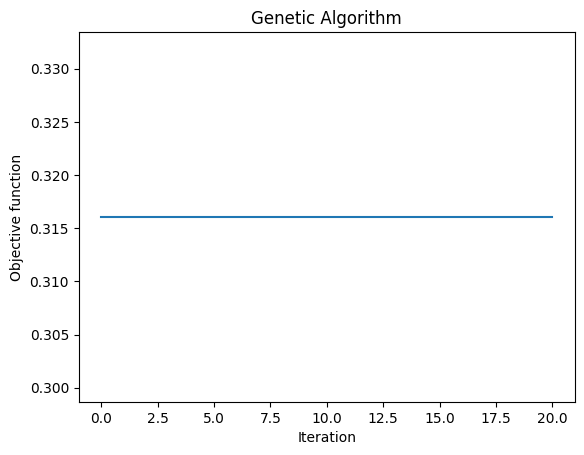

In [39]:
from geneticalgorithm import geneticalgorithm as ga
import numpy as np

# Variable bounds: [max_depth, min_samples_split]
varbound = np.array([[1, 20],  # max_depth
                     [2, 20]]) # min_samples_split

# Algorithm parameters including parents_portion
algorithm_params = {
    'max_num_iteration': 20,
    'population_size': 10,
    'mutation_probability': 0.1,
    'elit_ratio': 0.01,
    'crossover_probability': 0.5,
    'parents_portion': 0.3,
    'crossover_type': 'uniform',
    'max_iteration_without_improv': None
}

model = ga(function=dt_ga_objective,
           dimension=2,
           variable_type='int',
           variable_boundaries=varbound,
           algorithm_parameters=algorithm_params)

model.run()



In [ ]:

best_variables = model.output_dict['variable']

print("Best hyperparameters found by GA:")
print(f"max_depth = {int(best_variables[0])}, min_samples_split = {int(best_variables[1])}")
print(f"F1 Score: {dt_ga_f1:.4f}")
print(f"Specificity: {dt_ga_specificity:.4f}")


Best hyperparameters found by GA:
max_depth = 2, min_samples_split = 14
F1 Score: 0.6839
Specificity: 0.1538


## Decision Tree (BAT)

In [41]:
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, confusion_matrix

# Specificity function
def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp)


In [43]:
dt_bat_f1 = 0
dt_bat_specificity = 0

n_bats = 10
n_iter = 20
A = 0.5    
r = 0.5     
f_min = 0
f_max = 2

lb = np.array([1, 2])
ub = np.array([20, 20])

population = np.random.uniform(lb, ub, (n_bats, 2))
velocities = np.zeros_like(population)

def fitness(solution):
    global dt_bat_f1, dt_bat_specificity
    max_depth = int(solution[0])
    min_samples_split = int(solution[1])

    clf = DecisionTreeClassifier(max_depth=max_depth, min_samples_split=min_samples_split, random_state=42)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    dt_bat_f1 = f1_score(y_test, y_pred)
    dt_bat_specificity = specificity_score(y_test, y_pred)

    return 1 - dt_bat_f1 

fitness_values = np.array([fitness(bat) for bat in population])
best_idx = np.argmin(fitness_values)
best_bat = population[best_idx].copy()
best_fitness = fitness_values[best_idx]

for t in range(n_iter):
    for i in range(n_bats):
        f = f_min + (f_max - f_min) * np.random.rand()
        velocities[i] += (population[i] - best_bat) * f
        candidate = population[i] + velocities[i]

        candidate = np.clip(candidate, lb, ub)

        if np.random.rand() > r:
            candidate = best_bat + 0.001 * np.random.randn(2)

        Fnew = fitness(candidate)
        if Fnew <= fitness_values[i] and np.random.rand() < A:
            population[i] = candidate
            fitness_values[i] = Fnew

        if Fnew < best_fitness:
            best_bat = candidate.copy()
            best_fitness = Fnew


In [44]:
print("Best hyperparameters found by Bat Algorithm:")
print(f"max_depth = {int(best_bat[0])}, min_samples_split = {int(best_bat[1])}")
print(f"F1 Score: {dt_bat_f1:.4f}")
print(f"Specificity: {dt_bat_specificity:.4f}")


Best hyperparameters found by Bat Algorithm:
max_depth = 2, min_samples_split = 5
F1 Score: 0.6839
Specificity: 0.1538


## Decision Tree (ACO)

In [45]:
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, confusion_matrix

# Specificity function
def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp)


In [46]:
# Global variables to store metrics
dt_aco_f1 = 0
dt_aco_specificity = 0

def fitness(solution):
    global dt_aco_f1, dt_aco_specificity
    max_depth = int(solution[0])
    min_samples_split = int(solution[1])

    clf = DecisionTreeClassifier(max_depth=max_depth, min_samples_split=min_samples_split, random_state=42)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    dt_aco_f1 = f1_score(y_test, y_pred)
    dt_aco_specificity = specificity_score(y_test, y_pred)

    return 1 - dt_aco_f1  # minimize 1-F1


In [48]:
# ACO parameters
n_ants = 10
n_iter = 20
alpha = 1      # pheromone influence
beta = 2       # heuristic influence
rho = 0.1      # evaporation rate

# Bounds for hyperparameters
lb = np.array([1, 2])
ub = np.array([20, 20])

# Initialize pheromone matrix
pheromone = np.ones(2)  # one for each hyperparameter

# Heuristic: inverse of fitness at random positions
heuristic = np.zeros(2)

best_solution = None
best_fitness = np.inf

for it in range(n_iter):
    ants_solutions = []
    ants_fitness = []

    for k in range(n_ants):
        # Construct solution probabilistically
        solution = []
        for d in range(2):
            prob = (pheromone[d] ** alpha) * ((1 / (1e-6 + np.random.rand())) ** beta)
            val = lb[d] + prob * (ub[d] - lb[d])
            solution.append(val)
        solution = np.clip(solution, lb, ub)
        f = fitness(solution)

        ants_solutions.append(solution)
        ants_fitness.append(f)

        if f < best_fitness:
            best_solution = solution.copy()
            best_fitness = f

    # Update pheromone
# Update pheromone for each hyperparameter separately
for d in range(2):
    pheromone[d] = (1 - rho) * pheromone[d] + rho * np.mean([1/f for f in ants_fitness])


In [49]:
print("Best hyperparameters found by ACO:")
print(f"max_depth = {int(best_solution[0])}, min_samples_split = {int(best_solution[1])}")
print(f"F1 Score: {dt_aco_f1:.4f}")
print(f"Specificity: {dt_aco_specificity:.4f}")


Best hyperparameters found by ACO:
max_depth = 20, min_samples_split = 20
F1 Score: 0.6274
Specificity: 0.8205
